<a href="https://colab.research.google.com/github/pushkarkn/point-cloud-data-processing/blob/main/metrics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

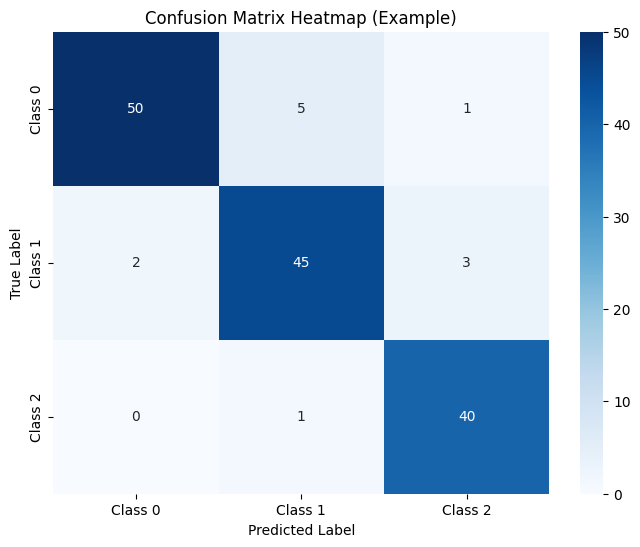

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


confusion_matrix_str = """
[[  50    5    1]
 [   2   45    3]
 [   0    1   40]]
"""

# Function to parse the string into a numpy array
def parse_confusion_matrix(matrix_str):
    # Remove brackets and split by lines
    lines = matrix_str.strip().replace('[', '').replace(']', '').split('\n')
    matrix = []
    for line in lines:
        if line.strip():
            # Convert each number to an integer
            matrix.append([int(x) for x in line.split() if x.isdigit()])
    return np.array(matrix)

# Parse the dummy confusion matrix
dummy_cm = parse_confusion_matrix(confusion_matrix_str)

# For better visualization, you might want to define class labels
# Replace ['Class 0', 'Class 1', 'Class 2'] with your actual class names
class_labels = [f'Class {i}' for i in range(dummy_cm.shape[0])]

plt.figure(figsize=(8, 6))
sns.heatmap(dummy_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Heatmap (Example)')
plt.show()

### Classification Report Analysis

The classification report provides a detailed breakdown of the performance of a classification model for each class. It includes precision, recall, F1-score, and support.

In [ ]:
import pandas as pd
import io

classification_report_str = """
                 precision    recall  f1-score   support

        class_0     0.0000    0.0000    0.0000        30
class_100000000     1.0000    0.0500    0.0952        40
class_202020000     0.9347    0.9838    0.9586     19535
class_202030000     0.8603    0.7405    0.7960      4783
class_202050000     0.9244    0.8800    0.9016       250
class_202060000     0.7364    0.5994    0.6609       317
class_203000000     0.8644    0.9553    0.9076     10109
class_302020200     0.0000    0.0000    0.0000         9
class_302020300     1.0000    0.0476    0.0909        21
class_302020400     0.3750    0.0233    0.0438       129
class_302020500     0.0000    0.0000    0.0000        16
class_302020600     0.8333    0.3279    0.4706        61
class_302020700     0.0000    0.0000    0.0000        33
class_302020900     0.0000    0.0000    0.0000         6
class_302021100     0.0000    0.0000    0.0000         2
class_302021200     0.0000    0.0000    0.0000         1
class_302021300     0.0000    0.0000    0.0000         2
class_302030200     1.0000    0.0192    0.0377        52
class_302030300     0.6889    0.9276    0.7907       456
class_302030600     0.0000    0.0000    0.0000         8
class_302030700     0.8052    0.2644    0.3981       469
class_302040500     0.0000    0.0000    0.0000         1
class_302040600     0.0000    0.0000    0.0000        27
class_302040700     0.0000    0.0000    0.0000         3
class_302040800     0.6000    0.4286    0.5000         7
class_303020000     0.0000    0.0000    0.0000        16
class_303030204     0.0000    0.0000    0.0000         4
class_303030504     0.0000    0.0000    0.0000         3
class_303040202     0.3333    0.0093    0.0180       108
class_303040204     0.7491    0.8522    0.7974      1272
class_303040302     0.8108    0.5556    0.6593        54
class_303040304     0.5000    0.1364    0.2143        44
class_303040404     0.9091    0.4167    0.5714        24
class_303040504     0.0000    0.0000    0.0000         4
class_303050500     0.8333    0.0625    0.1163        80
class_303050600     0.0000    0.0000    0.0000         1
class_304000000     0.6916    0.3227    0.4400       688
class_304020000     0.7857    0.6121    0.6881      1294
class_304040000     0.0000    0.0000    0.0000        41

       accuracy                         0.8889     40000
      macro avg     0.4163    0.2363    0.2604     40000
   weighted avg     0.8780    0.8889    0.8753     40000
"""

# Function to parse the classification report string
def parse_classification_report(report_str):
    report_io = io.StringIO(report_str)
    lines = report_io.readlines()

    # Skip initial empty lines and header
    data_lines = []
    header_found = False
    for line in lines:
        if line.strip() and not header_found and 'precision' in line:
            header_found = True
            continue # Skip the header line itself
        if header_found and line.strip():
            data_lines.append(line.strip())

    # Extract class-wise metrics
    class_metrics = []
    summary_metrics = []

    for line in data_lines:
        if 'avg' not in line and 'accuracy' not in line:
            parts = line.split()
            if len(parts) == 5:
                class_name = parts[0]
                precision = float(parts[1])
                recall = float(parts[2])
                f1_score = float(parts[3])
                support = int(parts[4])
                class_metrics.append([class_name, precision, recall, f1_score, support])
            elif len(parts) == 6: # Handle class names with spaces or long names
                class_name = parts[0] + '_' + parts[1]
                precision = float(parts[2])
                recall = float(parts[3])
                f1_score = float(parts[4])
                support = int(parts[5])
                class_metrics.append([class_name, precision, recall, f1_score, support])
        elif 'accuracy' in line:
            accuracy_val = float(line.split()[-2]) # Accuracy value
            total_support = int(line.split()[-1]) # Total support
            summary_metrics.append(['accuracy', accuracy_val, accuracy_val, accuracy_val, total_support])
        elif 'avg' in line:
            parts = line.split()
            avg_type = ' '.join(parts[:-4]) # e.g., 'macro avg', 'weighted avg'
            precision = float(parts[-4])
            recall = float(parts[-3])
            f1_score = float(parts[-2])
            support = int(parts[-1])
            summary_metrics.append([avg_type, precision, recall, f1_score, support])

    df_class = pd.DataFrame(class_metrics, columns=['Class', 'Precision', 'Recall', 'F1-Score', 'Support'])
    df_summary = pd.DataFrame(summary_metrics, columns=['Metric', 'Precision', 'Recall', 'F1-Score', 'Support'])
    return df_class, df_summary

df_class_report, df_summary_report = parse_classification_report(classification_report_str)

print("\n--- Class-wise Metrics ---")
display(df_class_report)

print("\n--- Overall and Average Metrics ---")
display(df_summary_report)


--- Class-wise Metrics ---


,Class,Precision,Recall,F1-Score,Support
0,class_0,0.0000,0.0000,0.0000,30
1,class_100000000,1.0000,0.0500,0.0952,40
2,class_202020000,0.9347,0.9838,0.9586,19535
3,class_202030000,0.8603,0.7405,0.7960,4783
4,class_202050000,0.9244,0.8800,0.9016,250
5,class_202060000,0.7364,0.5994,0.6609,317
6,class_203000000,0.8644,0.9553,0.9076,10109
7,class_302020200,0.0000,0.0000,0.0000,9
8,class_302020300,1.0000,0.0476,0.0909,21
9,class_302020400,0.3750,0.0233,0.0438,129



--- Overall and Average Metrics ---


,Metric,Precision,Recall,F1-Score,Support
0,accuracy,0.8889,0.8889,0.8889,40000
1,macro avg,0.4163,0.2363,0.2604,40000
2,weighted avg,0.8780,0.8889,0.8753,40000


### Visualizing the Classification Report

To better understand the performance across different classes, let's visualize the metrics from the classification report. We'll focus on classes that have actual support (i.e., at least one instance).

First, a plot showing Precision, Recall, and F1-Score for each class with non-zero support:

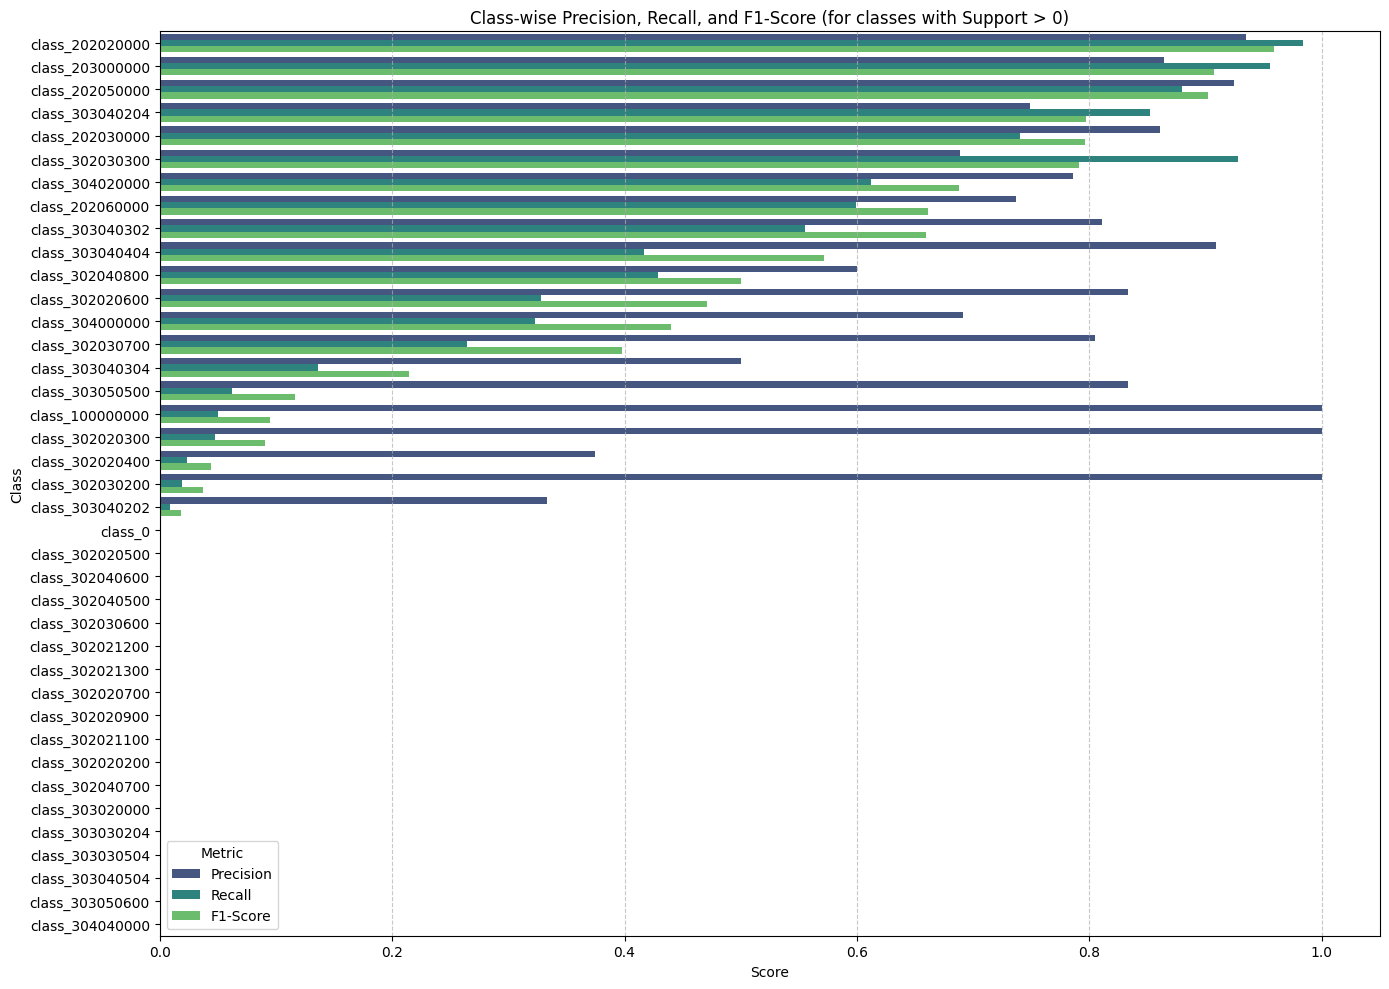

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter out classes with zero support for meaningful visualization
df_filtered = df_class_report[df_class_report['Support'] > 0].copy()

# Sort by F1-Score for better readability
df_filtered = df_filtered.sort_values(by='F1-Score', ascending=False)

# Prepare data for plotting Precision, Recall, F1-Score
df_plot = df_filtered[['Class', 'Precision', 'Recall', 'F1-Score']].melt(id_vars='Class', var_name='Metric', value_name='Score')

plt.figure(figsize=(14, 10))
sns.barplot(x='Score', y='Class', hue='Metric', data=df_plot, palette='viridis')
plt.title('Class-wise Precision, Recall, and F1-Score (for classes with Support > 0)')
plt.xlabel('Score')
plt.ylabel('Class')
plt.xlim(0, 1.05) # Scores are typically between 0 and 1
plt.legend(title='Metric')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Next, a bar chart to visualize the `Support` for each class. This helps in understanding the class imbalance and how many samples each class contributes to the overall metrics. Classes with very low support might have unstable metrics.

/tmp/ipykernel_1540/1034358285.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Support', y='Class', data=df_filtered, palette='coolwarm')


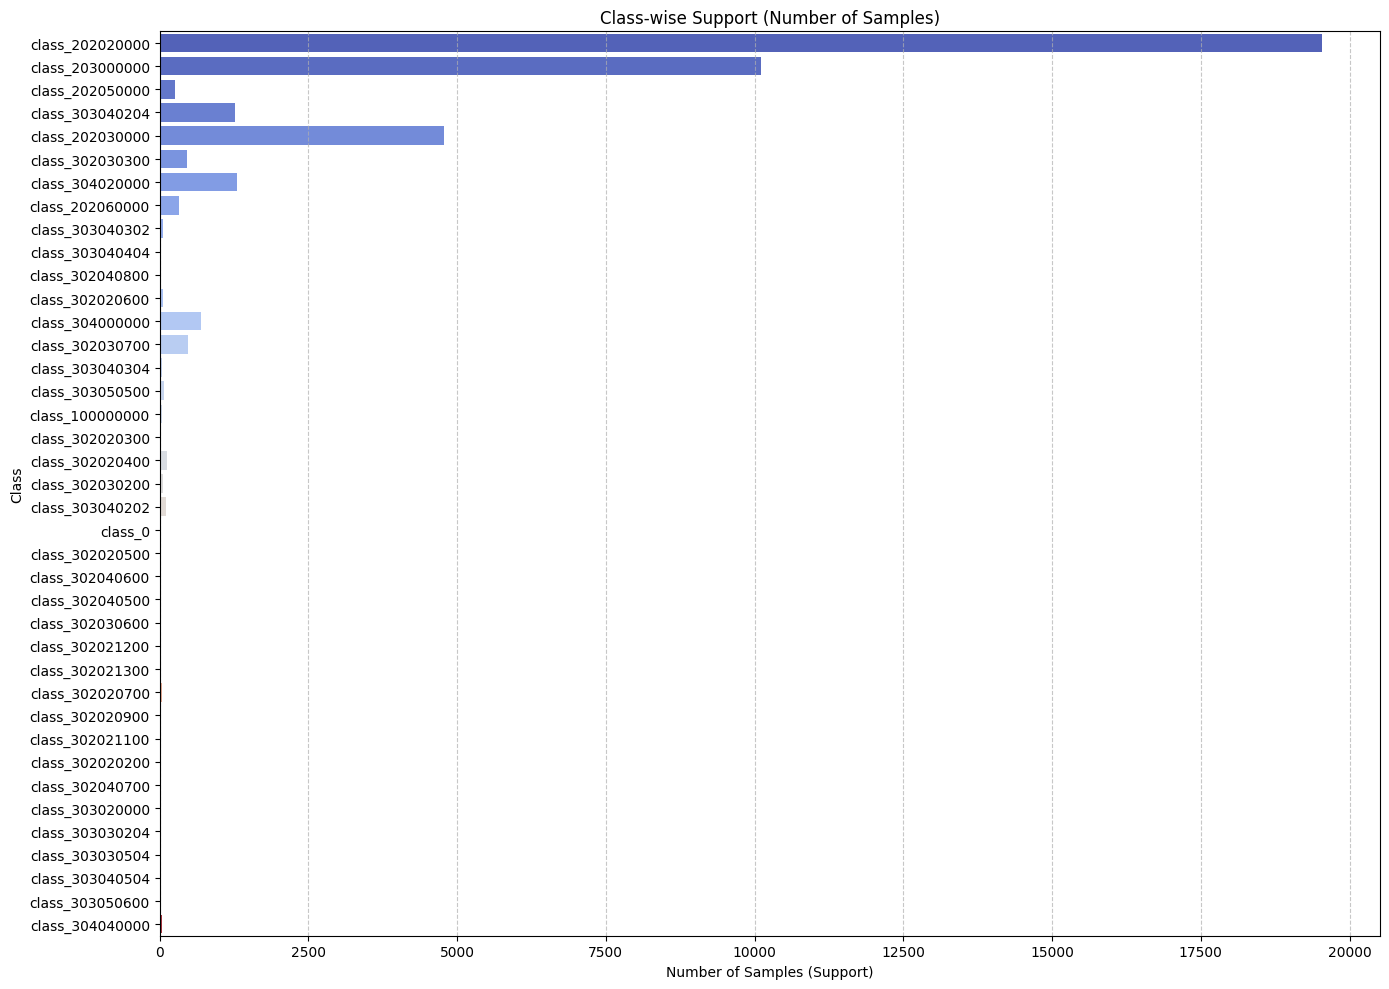

In [ ]:
plt.figure(figsize=(14, 10))
sns.barplot(x='Support', y='Class', data=df_filtered, palette='coolwarm')
plt.title('Class-wise Support (Number of Samples)')
plt.xlabel('Number of Samples (Support)')
plt.ylabel('Class')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Finally, a visualization of the overall and average metrics (accuracy, macro avg, weighted avg) from the summary report. These provide a consolidated view of the model's performance.

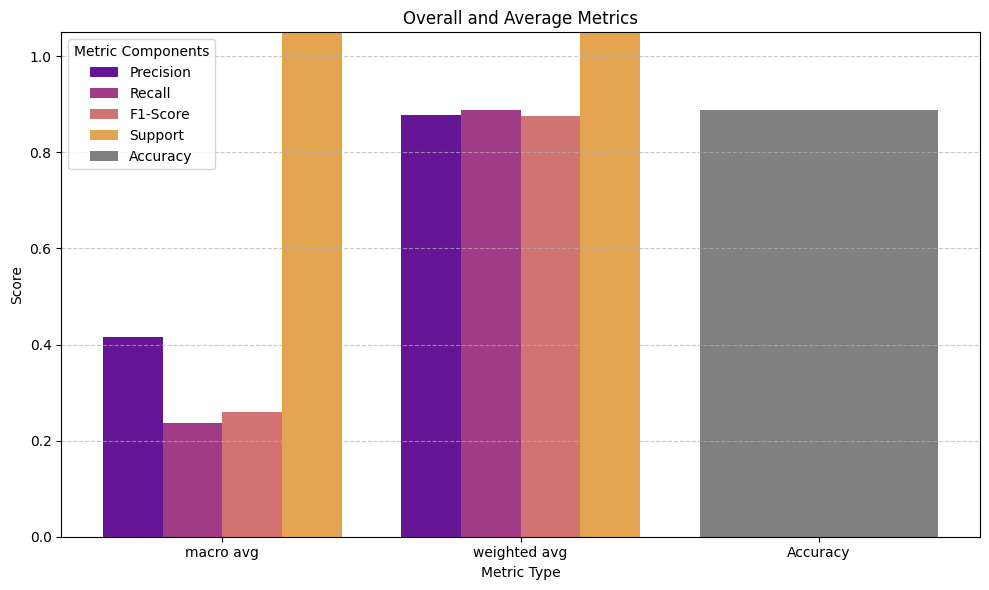

In [ ]:
# Prepare summary data for plotting
df_summary_plot = df_summary_report[df_summary_report['Metric'] != 'accuracy'].melt(id_vars='Metric', var_name='Type', value_name='Value')

plt.figure(figsize=(10, 6))
sns.barplot(x='Metric', y='Value', hue='Type', data=df_summary_plot, palette='plasma')

# Add accuracy as a separate bar or line for clarity, if desired.
# For simplicity, let's just add it as a separate bar here.
accuracy_row = df_summary_report[df_summary_report['Metric'] == 'accuracy']
plt.bar('Accuracy', accuracy_row['Precision'].iloc[0], color='gray', label='Accuracy')

plt.title('Overall and Average Metrics')
plt.xlabel('Metric Type')
plt.ylabel('Score')
plt.ylim(0, 1.05)
plt.legend(title='Metric Components')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Comparison of Baseline vs. Optimized Accuracy

Let's visualize the improvement from the baseline accuracy to the current optimized accuracy.

/tmp/ipykernel_1540/800731088.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Metric', y='Value', data=accuracy_comparison_df, palette=['lightcoral', 'mediumseagreen'])


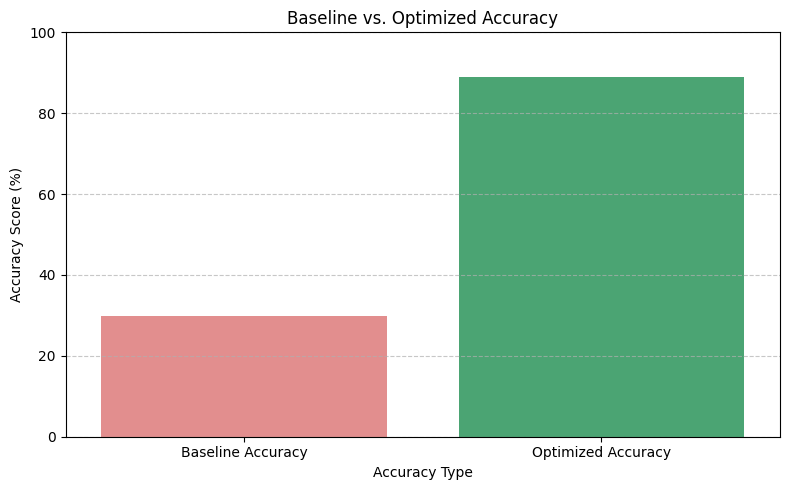

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extract baseline and current accuracy from the initial text
# For demonstration, I'll use the values you provided earlier.
baseline_accuracy = 0.2989
optimized_accuracy = 0.8889

# Create a DataFrame for plotting
accuracy_comparison_df = pd.DataFrame({
    'Metric': ['Baseline Accuracy', 'Optimized Accuracy'],
    'Value': [baseline_accuracy * 100, optimized_accuracy * 100]  # Convert to percentage
})

plt.figure(figsize=(8, 5))
sns.barplot(x='Metric', y='Value', data=accuracy_comparison_df, palette=['lightcoral', 'mediumseagreen'])
plt.title('Baseline vs. Optimized Accuracy')
plt.xlabel('Accuracy Type')
plt.ylabel('Accuracy Score (%)')  # Update y-axis label
plt.ylim(0, 100) # Update y-axis limit for percentages
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Training and Validation Metrics Over Epochs

Let's visualize the training and validation loss and accuracy over the epochs to observe the model's learning progress.

In [ ]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

training_log = """
Loading PLY: Lille1.ply
Training on cpu | classes=39 | samples=200000
Epoch 001/35 | train_loss=1.2870 train_acc=0.6880 | val_loss=0.8559 val_acc=0.7322
Epoch 002/35 | train_loss=0.8259 train_acc=0.7431 | val_loss=0.7506 val_acc=0.7529
Epoch 003/35 | train_loss=0.7600 train_acc=0.7581 | val_loss=0.6959 val_acc=0.7710
Epoch 004/35 | train_loss=0.7215 train_acc=0.7691 | val_loss=0.6489 val_acc=0.7823
Epoch 005/35 | train_loss=0.6805 train_acc=0.7826 | val_loss=0.6182 val_acc=0.8017
Epoch 006/35 | train_loss=0.6376 train_acc=0.7960 | val_loss=0.5558 val_acc=0.8037
Epoch 007/35 | train_loss=0.5999 train_acc=0.8108 | val_loss=0.5600 val_acc=0.8175
Epoch 008/35 | train_loss=0.5740 train_acc=0.8184 | val_loss=0.4918 val_acc=0.8456
Epoch 009/35 | train_loss=0.5634 train_acc=0.8200 | val_loss=0.4834 val_acc=0.8388
Epoch 010/35 | train_loss=0.5441 train_acc=0.8268 | val_loss=0.4954 val_acc=0.8351
Epoch 011/35 | train_loss=0.5275 train_acc=0.8320 | val_loss=0.4602 val_acc=0.8458
Epoch 012/35 | train_loss=0.5163 train_acc=0.8350 | val_loss=0.4786 val_acc=0.8377
Epoch 013/35 | train_loss=0.5052 train_acc=0.8392 | val_loss=0.4400 val_acc=0.8545
Epoch 014/35 | train_loss=0.4997 train_acc=0.8414 | val_loss=0.4643 val_acc=0.8453
Epoch 015/35 | train_loss=0.4918 train_acc=0.8435 | val_loss=0.4316 val_acc=0.8624
Epoch 016/35 | train_loss=0.4883 train_acc=0.8436 | val_loss=0.4223 val_acc=0.8571
Epoch 017/35 | train_loss=0.4766 train_acc=0.8486 | val_loss=0.5106 val_acc=0.8161
Epoch 018/35 | train_loss=0.4702 train_acc=0.8487 | val_loss=0.4029 val_acc=0.8612
Epoch 019/35 | train_loss=0.4520 train_acc=0.8557 | val_loss=0.3820 val_acc=0.8751
Epoch 020/35 | train_loss=0.4445 train_acc=0.8580 | val_loss=0.3773 val_acc=0.8769
Epoch 021/35 | train_loss=0.4454 train_acc=0.8577 | val_loss=0.4031 val_acc=0.8636
Epoch 022/35 | train_loss=0.4412 train_acc=0.8592 | val_loss=0.3825 val_acc=0.8692
Epoch 023/35 | train_loss=0.4340 train_acc=0.8614 | val_loss=0.3796 val_acc=0.8719
Epoch 024/35 | train_loss=0.4283 train_acc=0.8643 | val_loss=0.3606 val_acc=0.8821
Epoch 025/35 | train_loss=0.4264 train_acc=0.8646 | val_loss=0.3701 val_acc=0.8756
Epoch 026/35 | train_loss=0.4232 train_acc=0.8656 | val_loss=0.3622 val_acc=0.8791
Epoch 027/35 | train_loss=0.4236 train_acc=0.8635 | val_loss=0.3690 val_acc=0.8782
Epoch 028/35 | train_loss=0.4175 train_acc=0.8666 | val_loss=0.3584 val_acc=0.8808
Epoch 029/35 | train_loss=0.4155 train_acc=0.8676 | val_loss=0.3522 val_acc=0.8866
Epoch 030/35 | train_loss=0.4146 train_acc=0.8680 | val_loss=0.3549 val_acc=0.8819
Epoch 031/35 | train_loss=0.4139 train_acc=0.8678 | val_loss=0.3523 val_acc=0.8831
Epoch 032/35 | train_loss=0.4111 train_acc=0.8696 | val_loss=0.3496 val_acc=0.8862
Epoch 033/35 | train_loss=0.4121 train_acc=0.8690 | val_loss=0.3473 val_acc=0.8862
Epoch 034/35 | train_loss=0.4109 train_acc=0.8695 | val_loss=0.3491 val_acc=0.8852
Epoch 035/35 | train_loss=0.4078 train_acc=0.8702 | val_loss=0.3510 val_acc=0.8834

=== Test Metrics ===
Test Loss: 0.3503
Test Accuracy: 0.8889
"""

# Regex to extract the data for each epoch
epoch_pattern = re.compile(r"Epoch (\d+)/\d+ \| train_loss=([\d.]+) train_acc=([\d.]+) \| val_loss=([\d.]+) val_acc=([\d.]+)")

data = []
for line in training_log.split('\n'):
    match = epoch_pattern.match(line)
    if match:
        epoch, train_loss, train_acc, val_loss, val_acc = match.groups()
        data.append({
            'Epoch': int(epoch),
            'Train Loss': float(train_loss),
            'Train Accuracy': float(train_acc),
            'Validation Loss': float(val_loss),
            'Validation Accuracy': float(val_acc)
        })

df_metrics = pd.DataFrame(data)
display(df_metrics.head())

# Extract Test Metrics
test_loss_match = re.search(r"Test Loss: ([\d.]+)", training_log)
test_accuracy_match = re.search(r"Test Accuracy: ([\d.]+)", training_log)

test_loss = float(test_loss_match.group(1)) if test_loss_match else None
test_accuracy = float(test_accuracy_match.group(1)) if test_accuracy_match else None

print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")


,Epoch,Train Loss,Train Accuracy,Validation Loss,Validation Accuracy
0,1,1.2870,0.6880,0.8559,0.7322
1,2,0.8259,0.7431,0.7506,0.7529
2,3,0.7600,0.7581,0.6959,0.7710
3,4,0.7215,0.7691,0.6489,0.7823
4,5,0.6805,0.7826,0.6182,0.8017



Test Loss: 0.3503
Test Accuracy: 0.8889


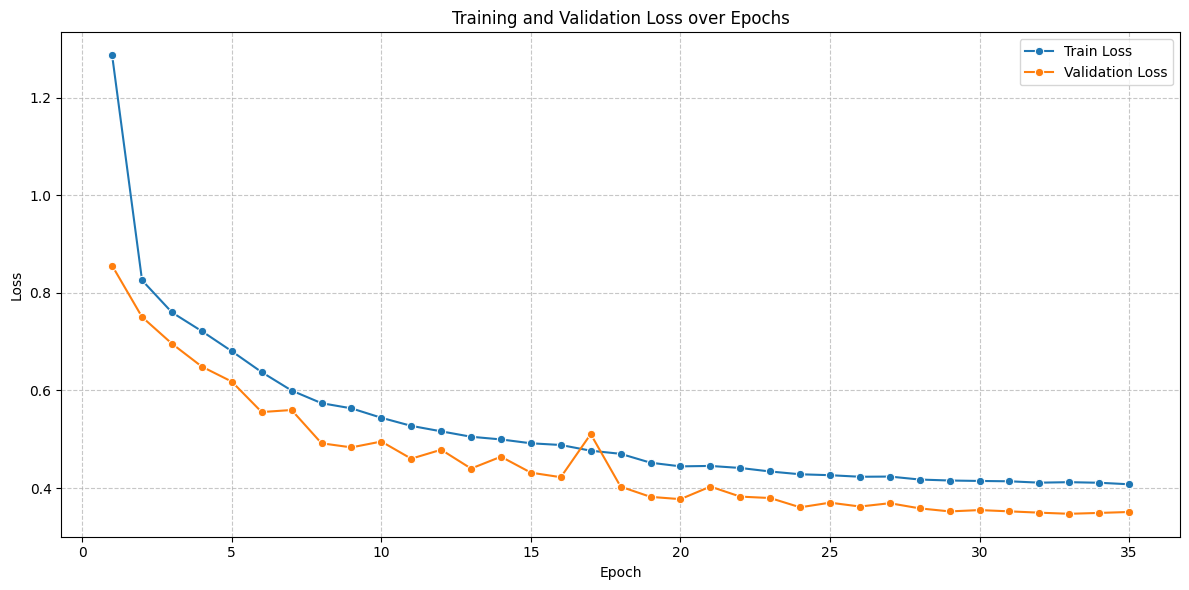

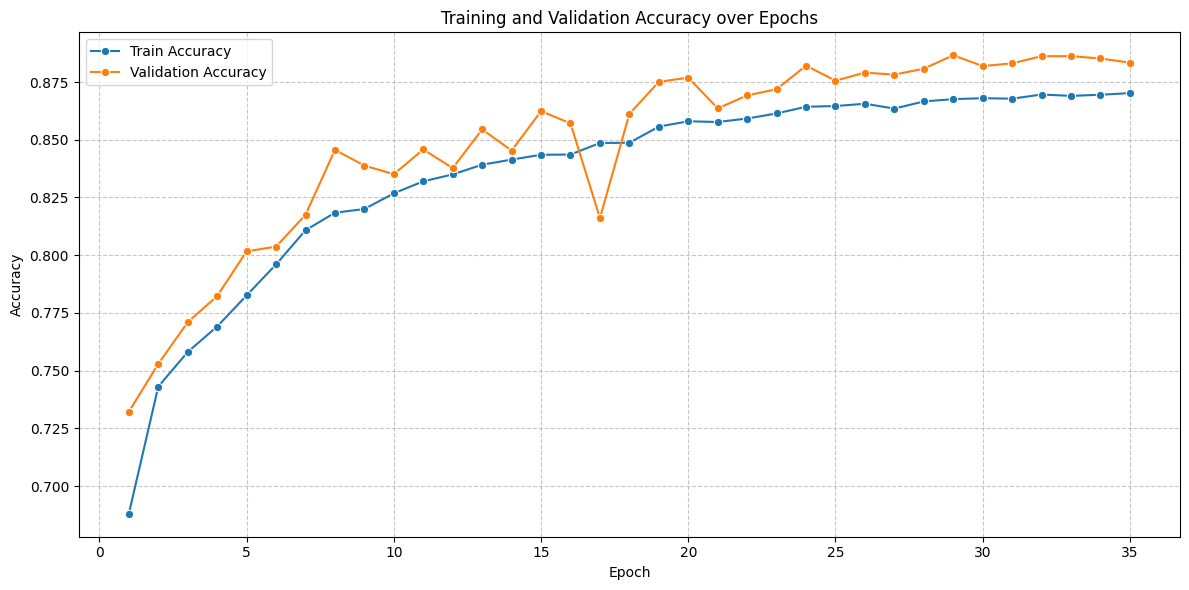

In [ ]:
# Plotting Training and Validation Loss
plt.figure(figsize=(12, 6))
sns.lineplot(x='Epoch', y='Train Loss', data=df_metrics, label='Train Loss', marker='o')
sns.lineplot(x='Epoch', y='Validation Loss', data=df_metrics, label='Validation Loss', marker='o')
plt.title('Training and Validation Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

# Plotting Training and Validation Accuracy
plt.figure(figsize=(12, 6))
sns.lineplot(x='Epoch', y='Train Accuracy', data=df_metrics, label='Train Accuracy', marker='o')
sns.lineplot(x='Epoch', y='Validation Accuracy', data=df_metrics, label='Validation Accuracy', marker='o')
plt.title('Training and Validation Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()
